## Ejercicio 3: Inspección visual de un producto

### Ficha PEAS

| Componente | Descripción |
| :--- | :--- |
| **Percepción (S)** | Matriz NumPy 5x5 de píxeles (0 = normal, 1 = defectuoso). |
| **Acciones (A)** | Aprobar producto (`"aprobar"`), Enviar a revisión manual (`"revision manual"`), Rechazar producto (`"rechazar"`). |
| **Entorno (E)** | Banda de producción automatizada y sensor/cámara de visión artificial. |
| **Objetivo** | Garantizar el control de calidad detectando fallas sin descartar innecesariamente piezas recuperables. |
| **Medida de desempeño (P)** | Tasa de detección de defectos, porcentaje de falsos descartes y velocidad de inspección por producto. |

### Justificación de las reglas
Las reglas buscan equilibrar la calidad del producto y la eficiencia del proceso. Un producto sin píxeles defectuosos se aprueba inmediatamente al cumplir los estándares. Si tiene entre 1 y 3 píxeles defectuosos, se deriva a revisión manual para evaluar si la falla es corregible o un error menor de lectura. Si excede los 3 píxeles defectuosos, la falla es estructural y requiere rechazo automático para no comprometer la calidad del lote.

In [1]:
### Código
import numpy as np

def agente_inspeccion(imagen):
    """
    Percepción (S): matriz 5x5 de NumPy (0 = normal, 1 = defectuoso)
    """
    defectos = np.sum(imagen == 1)
    
    if defectos == 0:
        return "aprobar", "Producto impecable sin pixeles defectuosos"
    elif defectos <= 3:
        return "revision manual", f"Se detectaron {defectos} pixeles defectuosos (dentro del limite condicional de 1 a 3)"
    else:
        return "rechazar", f"Se detectaron {defectos} pixeles defectuosos (excede el limite maximo de 3)"

--- RESULTADOS DE SIMULACIÓN DE INSPECCIÓN VISUAL ---
Matriz Sin Defectos:
  -> Decisión: APROBAR | Motivo: Producto impecable sin pixeles defectuosos

Matriz Con 1 Defecto:
  -> Decisión: REVISION MANUAL | Motivo: Se detectaron 1 pixeles defectuosos (dentro del limite condicional de 1 a 3)

Matriz Borde (3 Defectos):
  -> Decisión: REVISION MANUAL | Motivo: Se detectaron 3 pixeles defectuosos (dentro del limite condicional de 1 a 3)

Matriz Defectuosa (5 Defectos):
  -> Decisión: RECHAZAR | Motivo: Se detectaron 5 pixeles defectuosos (excede el limite maximo de 3)



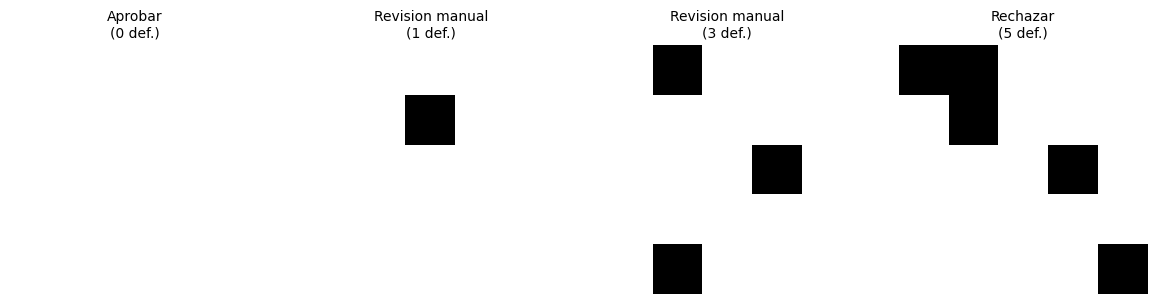

In [2]:
### Simulación y pruebas
import matplotlib.pyplot as plt

# Definir matrices 5x5 de prueba
img_perfecta = np.zeros((5, 5), dtype=int)

img_un_defecto = np.array([
    [0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0]
])

img_borde_aceptable = np.array([
    [0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0]
]) # Exactamente 3 defectos (Caso Borde)

img_rechazada = np.array([
    [1, 1, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1]
]) # 5 defectos

matriz_pruebas = [
    ("Matriz Sin Defectos", img_perfecta),
    ("Matriz Con 1 Defecto", img_un_defecto),
    ("Matriz Borde (3 Defectos)", img_borde_aceptable),
    ("Matriz Defectuosa (5 Defectos)", img_rechazada)
]

print("--- RESULTADOS DE SIMULACIÓN DE INSPECCIÓN VISUAL ---")
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for i, (nombre, img) in enumerate(matriz_pruebas):
    accion, motivo = agente_inspeccion(img)
    print(f"{nombre}:")
    print(f"  -> Decisión: {accion.upper()} | Motivo: {motivo}\n")
    
    axes[i].imshow(img, cmap="gray_r")
    axes[i].set_title(f"{accion.capitalize()}\n({np.sum(img==1)} def.)", fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()